# Credit Default Risk Prediction in Personal Loan Application


In [1]:
!pip install imbalanced-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import lime
import lime.lime_tabular

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, matthews_corrcoef, brier_score_loss
)
from sklearn.calibration import calibration_curve
from imblearn.over_sampling import SMOTE


Initial data shape: (32581, 12)
Data shape after dropping NaNs: (28638, 15)


use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.


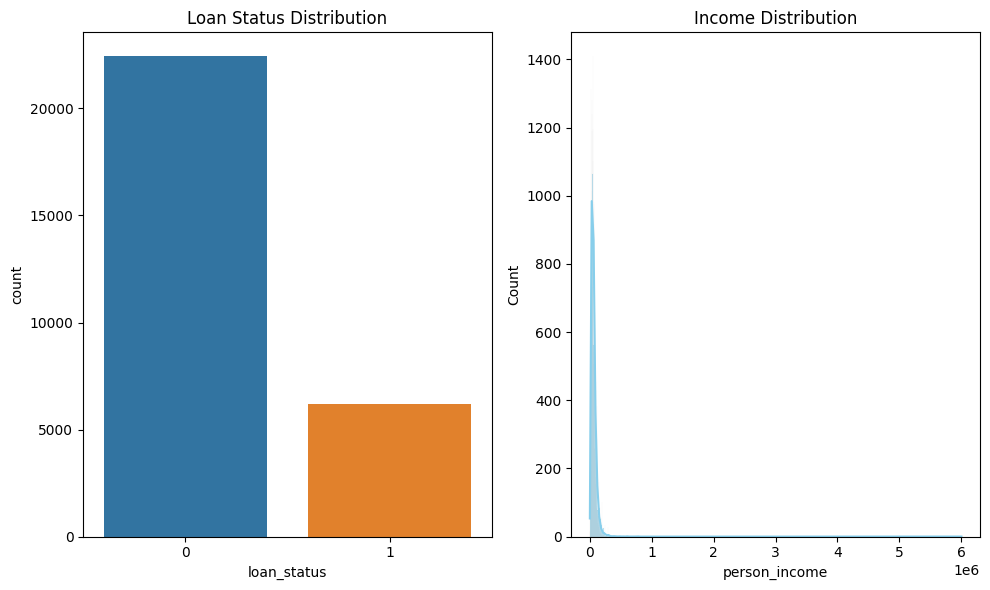

`sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
invalid value encountered in less


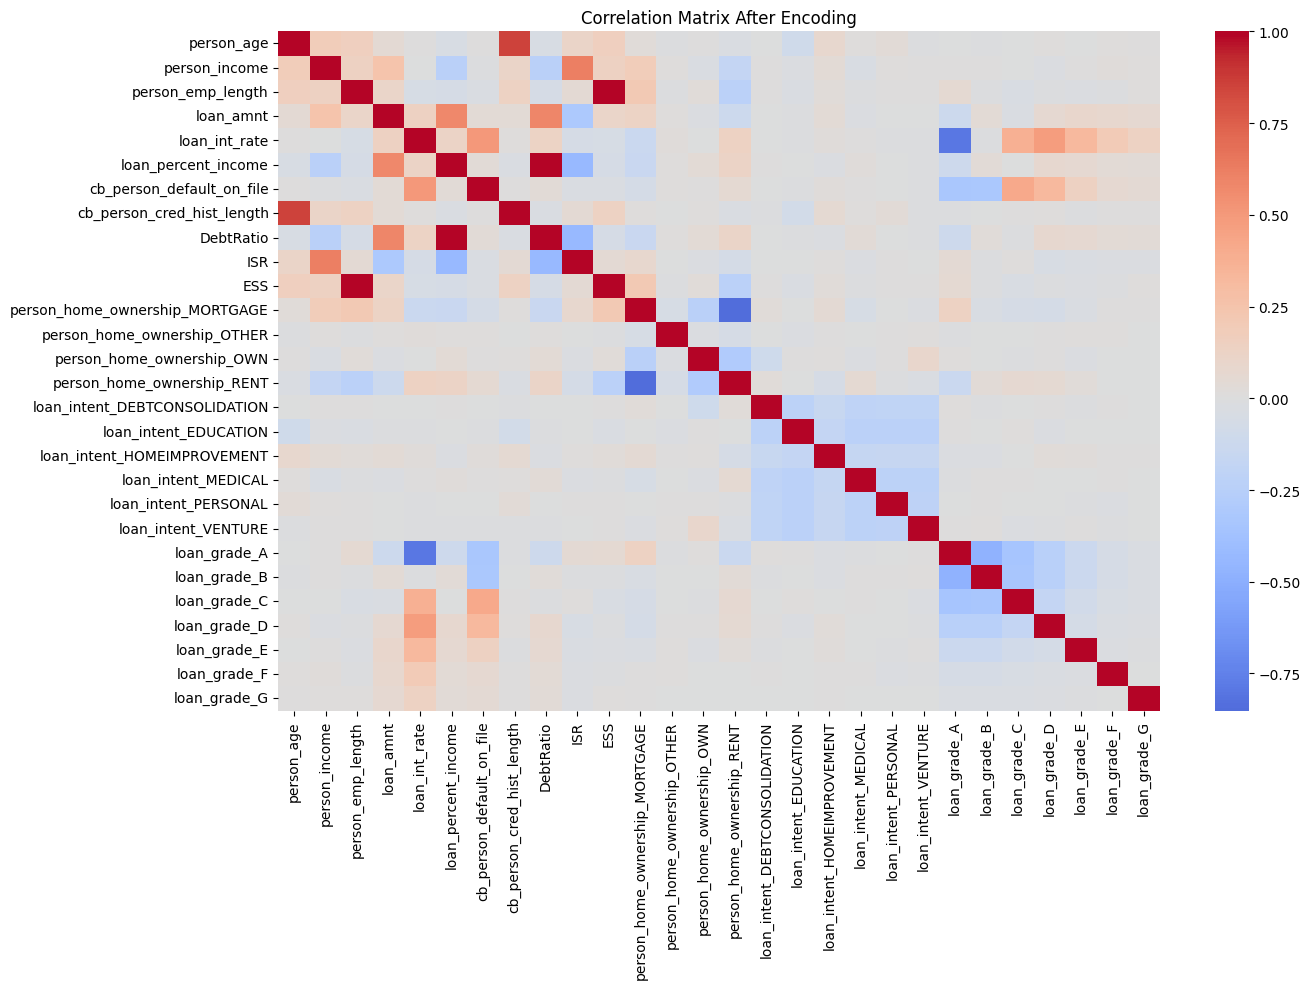

Shape after SMOTE: (35896, 28)
Evaluation Metrics:
Accuracy: 0.9298
Precision: 0.9430
Recall: 0.7196
F1-Score: 0.8163
AUC: 0.9267
MCC: 0.7847
Brier Score: 0.0633


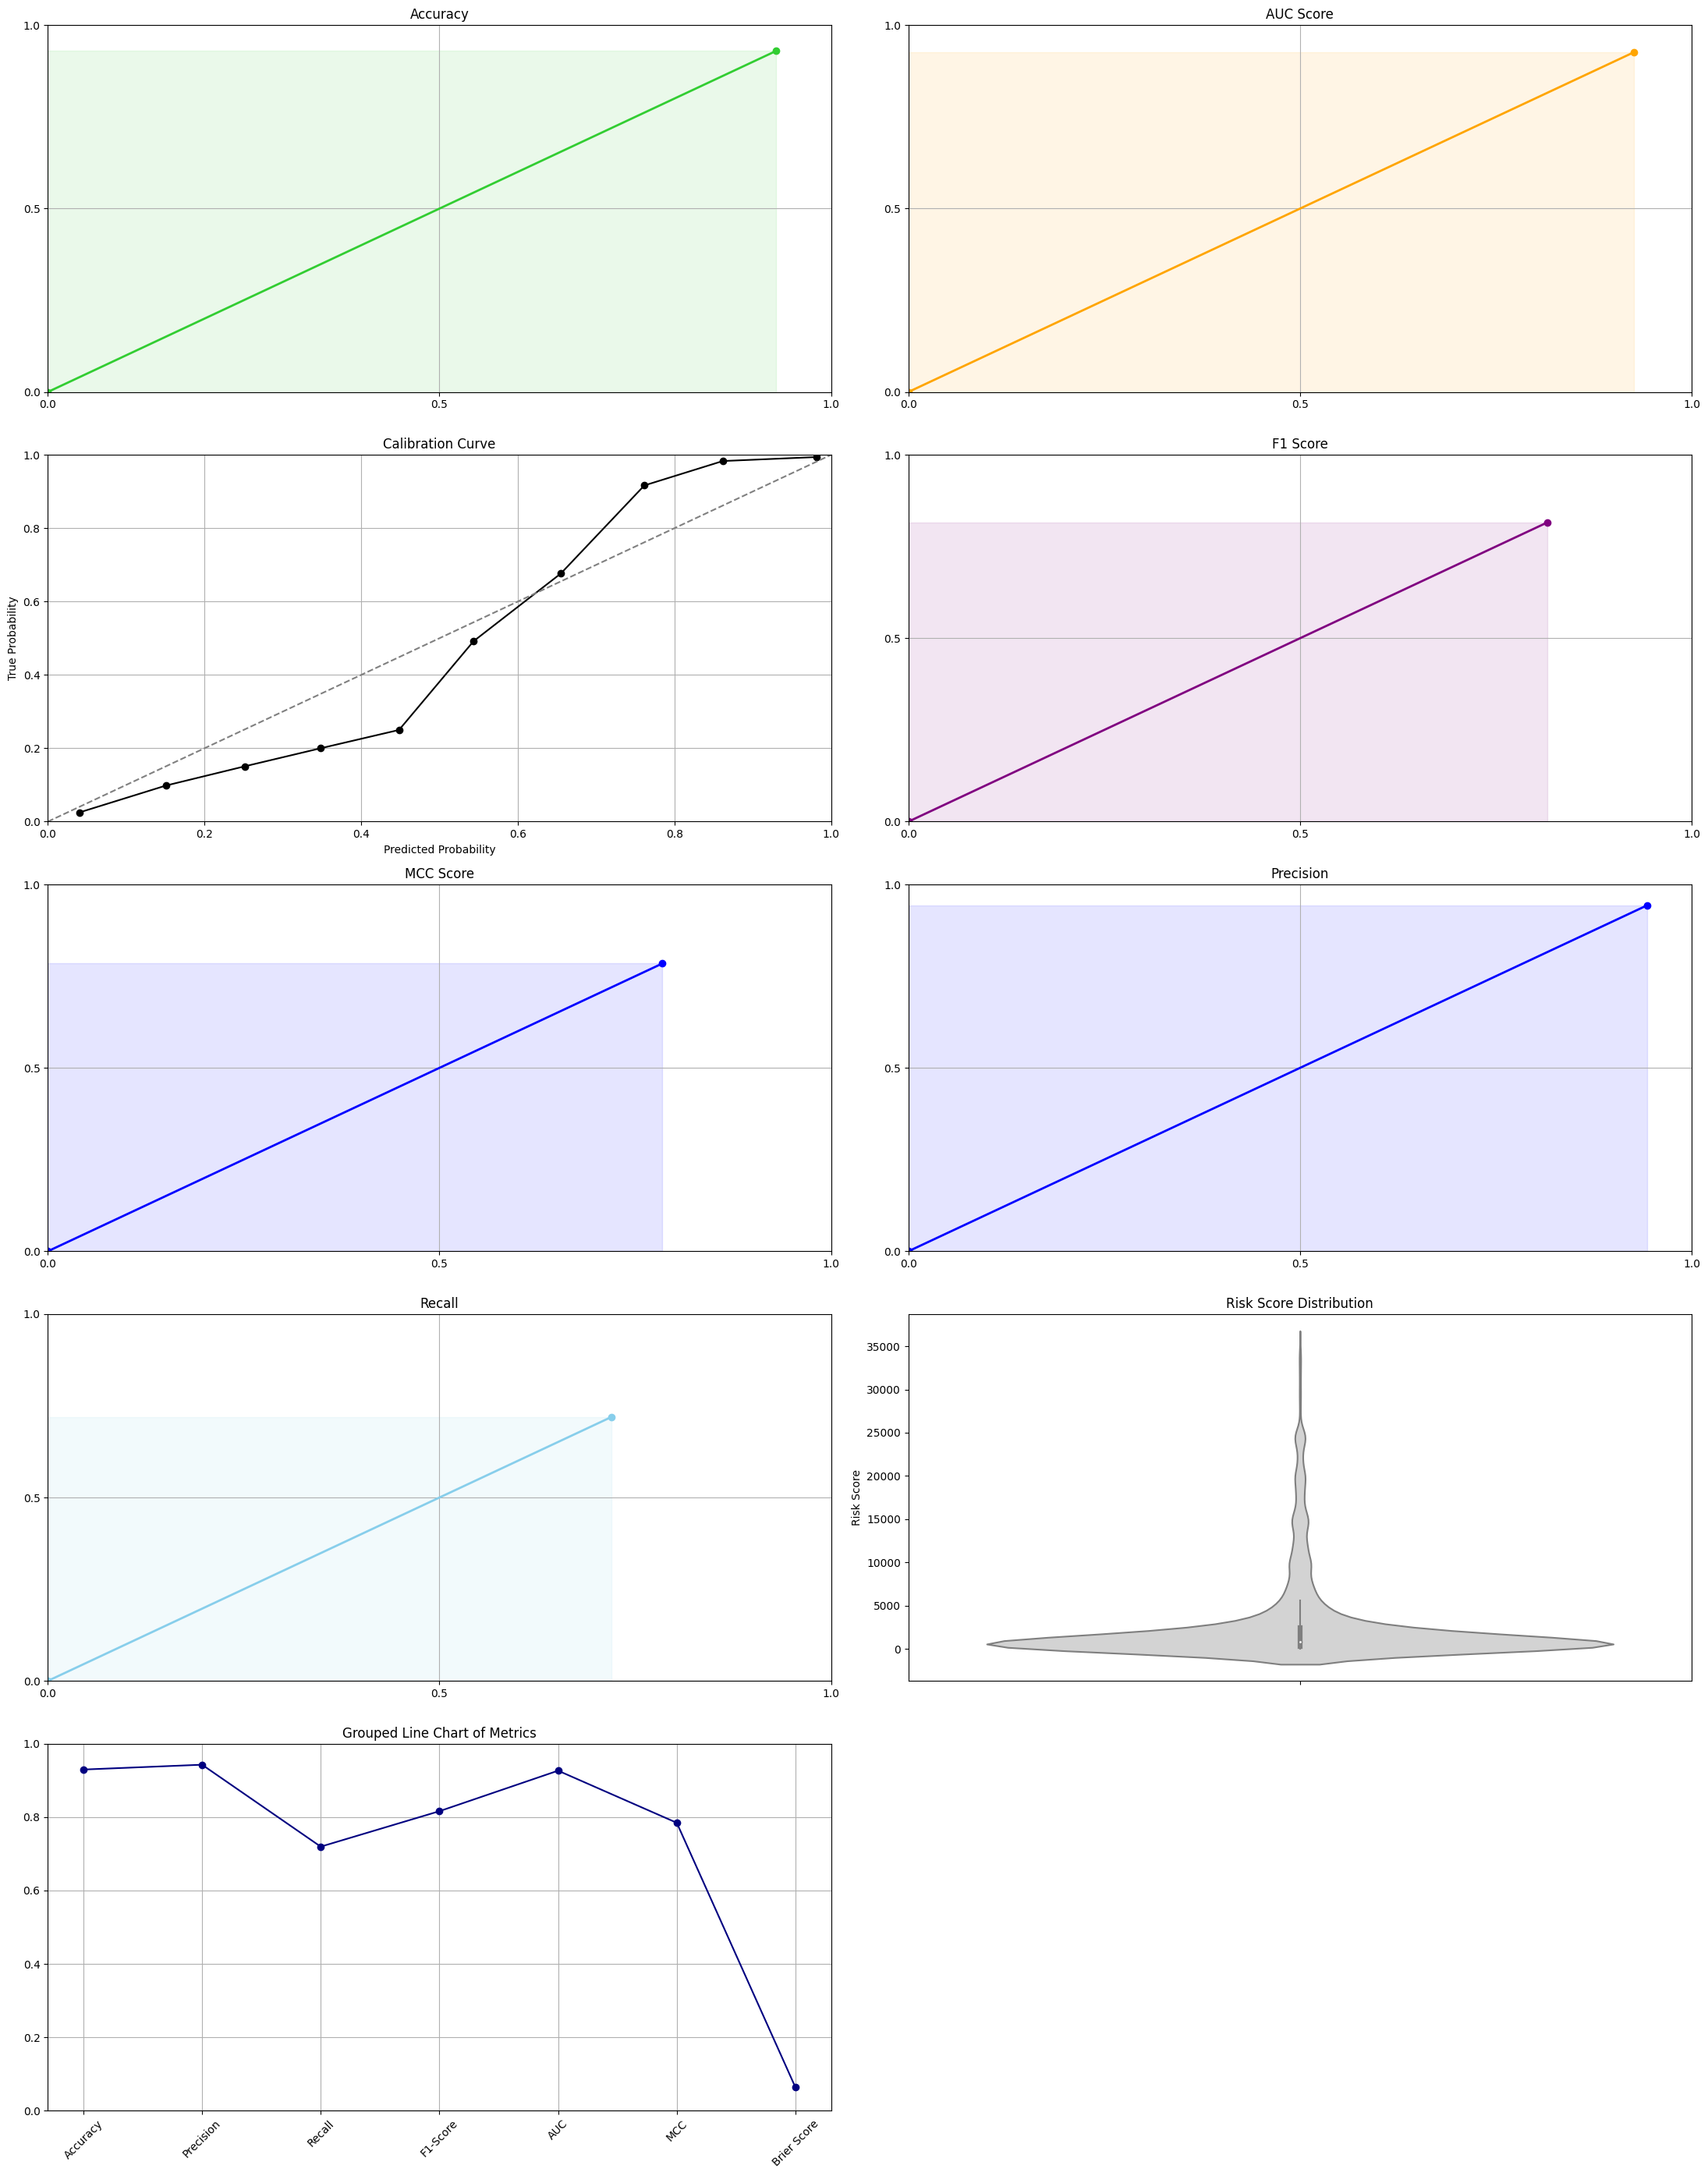

In [7]:
# ============================ DATA LOADING ============================
df = pd.read_csv("/kaggle/input/credit-risk-dataset/credit_risk_dataset.csv")
print("Initial data shape:", df.shape)

# ============================ FEATURE ENGINEERING ============================
df['cb_person_default_on_file'] = df['cb_person_default_on_file'].map({'Y': 1, 'N': 0})
df['DebtRatio'] = df['loan_amnt'] / (df['person_income'] + 1)
df['ISR'] = df['person_income'] / (df['loan_amnt'] + 1)
df['ESS'] = df['person_emp_length'] / 36
df.dropna(inplace=True)
print("Data shape after dropping NaNs:", df.shape)

# ============================ EDA ============================
plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
sns.countplot(data=df, x='loan_status')
plt.title('Loan Status Distribution')

plt.subplot(1, 2, 2)
sns.histplot(df['person_income'], kde=True, color='skyblue')
plt.title('Income Distribution')
plt.tight_layout()
plt.show()

# ============================ SPLIT ============================
y = df['loan_status']
X = df.drop(['loan_status'], axis=1)
cat_features = ['person_home_ownership', 'loan_intent', 'loan_grade']
num_features = [c for c in X.columns if c not in cat_features]

# ============================ PREPROCESSING ============================
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse=False))
])
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, num_features),
    ('cat', categorical_transformer, cat_features)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

# Get readable feature names
encoded_num = num_features  # original numeric names are preserved after scaling
encoded_cat = preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(cat_features)
feature_names = np.concatenate([encoded_num, encoded_cat])

# ============================ CORRELATION MATRIX AFTER ENCODING ============================
X_encoded_df = pd.DataFrame(X_train_proc, columns=feature_names)
plt.figure(figsize=(14, 10))
sns.heatmap(X_encoded_df.corr(), cmap='coolwarm', center=0)
plt.title("Correlation Matrix After Encoding")
plt.tight_layout()
plt.show()

# ============================ RESAMPLING ============================
X_train_res, y_train_res = SMOTE(random_state=42).fit_resample(X_train_proc, y_train)
print("Shape after SMOTE:", X_train_res.shape)

# ============================ MODEL ============================
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_res, y_train_res)
y_pred = model.predict(X_test_proc)
y_prob = model.predict_proba(X_test_proc)[:, 1]

# ============================ METRICS ============================
metrics_dict = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1-Score': f1_score(y_test, y_pred),
    'AUC': roc_auc_score(y_test, y_prob),
    'MCC': matthews_corrcoef(y_test, y_pred),
    'Brier Score': brier_score_loss(y_test, y_prob)
}
print("Evaluation Metrics:")
for k, v in metrics_dict.items():
    print(f"{k}: {v:.4f}")

# ============================ LIME ============================
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_res,
    feature_names=feature_names,
    class_names=['Non-Default', 'Default'],
    mode='classification'
)
lime_exp = lime_explainer.explain_instance(
    X_test_proc[0],
    model.predict_proba,
    num_features=10
)
lime_exp.show_in_notebook()

# ============================ CALIBRATION ============================
prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)

# ============================ RISK SCORE ============================
df_test = X_test.copy()
df_test['risk_score'] = y_prob * df_test['loan_amnt']

# ============================ EVALUATION LINE PLOTS ============================
fig, axs = plt.subplots(5, 2, figsize=(22, 28))
axs = axs.flatten()

def metric_line(ax, label, value, color):
    ax.plot([0, value], [0, value], linestyle='-', marker='o', color=color, linewidth=2)
    ax.fill_between([0, value], [0, 0], [value, value], color=color, alpha=0.1)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_title(label)
    ax.set_xticks([0, 0.5, 1])
    ax.set_yticks([0, 0.5, 1])
    ax.grid(True)

# Line Plots
metric_line(axs[0], 'Accuracy', metrics_dict['Accuracy'], 'limegreen')
metric_line(axs[1], 'AUC Score', metrics_dict['AUC'], 'orange')
axs[2].plot(prob_pred, prob_true, marker='o', linestyle='-', color='black')
axs[2].plot([0, 1], [0, 1], linestyle='--', color='gray')
axs[2].set_title('Calibration Curve')
axs[2].set_xlabel('Predicted Probability')
axs[2].set_ylabel('True Probability')
axs[2].set_xlim(0, 1)
axs[2].set_ylim(0, 1)
axs[2].grid(True)
metric_line(axs[3], 'F1 Score', metrics_dict['F1-Score'], 'purple')
metric_line(axs[4], 'MCC Score', metrics_dict['MCC'], 'blue')
metric_line(axs[5], 'Precision', metrics_dict['Precision'], 'blue')
metric_line(axs[6], 'Recall', metrics_dict['Recall'], 'skyblue')

# Risk Score Violin Plot
sns.violinplot(data=df_test, y='risk_score', ax=axs[7], color='lightgray')
axs[7].set_title('Risk Score Distribution')
axs[7].set_ylabel('Risk Score')

# Grouped Line for All Metrics
metric_labels = list(metrics_dict.keys())
metric_vals = list(metrics_dict.values())
axs[8].plot(metric_labels, metric_vals, marker='o', linestyle='-', color='navy')
axs[8].set_ylim(0, 1)
axs[8].set_title('Grouped Line Chart of Metrics')
axs[8].tick_params(axis='x', rotation=45)
axs[8].grid(True)

# Empty subplot
axs[9].axis('off')

plt.tight_layout()
plt.show()
